Import Libraries

In [361]:
# =========================================
# IMPORT LIBRARIES
# =========================================
import pandas as pd

from pyomo.environ import (
    ConcreteModel, Set, Param, Var,
    Constraint, Objective,
    NonNegativeReals, Binary,
    SolverFactory, minimize, value
)

Read Data

In [362]:
# =========================================
# READ DATA FROM EXCEL
# =========================================

file_path = r"D:\UGM\Tugas Akhir\UC Coding\Belajar\DataSet_R01.xlsx"   # ganti sesuai nama file Anda

# Generator data
gen_df = pd.read_excel(file_path, sheet_name="Gen")

# Demand data
demand_df = pd.read_excel(file_path, sheet_name="Demand")

# Jika data tidak diisi
gen_df['Droop'] = gen_df['Droop'].fillna(0.0)
gen_df['PFR_Fraction'] = gen_df['PFR_Fraction'].fillna(0.0)
gen_df['FreeGovernor'] = gen_df['FreeGovernor'].fillna(0).astype(int)

# Tampilkan untuk cek
#print(gen_df.head())
#print(demand_df.head())

Data Frame

In [363]:
# ============================
# CONVERT DATAFRAME → DICTIONARY
# ============================

# Set generator
G = gen_df['Unit'].tolist()

# Set time
T = demand_df['Hour'].tolist()

# Parameter generator
Pmin = dict(zip(gen_df['Unit'], gen_df['Pmin']))
Pmax = dict(zip(gen_df['Unit'], gen_df['Pmax']))
a = dict(zip(gen_df['Unit'], gen_df['a']))
b = dict(zip(gen_df['Unit'], gen_df['b']))
c = dict(zip(gen_df['Unit'], gen_df['c']))

SU_cost = dict(zip(gen_df['Unit'], gen_df['SU_Cost']))
SD_cost = dict(zip(gen_df['Unit'], gen_df['SD_Cost']))

RampUp = dict(zip(gen_df['Unit'], gen_df['Ramp_Up']))
RampDown = dict(zip(gen_df['Unit'], gen_df['Ramp_Down']))

MinUp = dict(zip(gen_df['Unit'], gen_df['Min_Up']))
MinDown = dict(zip(gen_df['Unit'], gen_df['Min_Down']))

# Demand
Demand = dict(zip(demand_df['Hour'], demand_df['Demand']))

# Frequency
Droop = dict(zip(gen_df['Unit'], gen_df['Droop']))
PFR_Fraction = dict(zip(gen_df['Unit'], gen_df['PFR_Fraction']))
FreeGovernor = dict(zip(gen_df['Unit'], gen_df['FreeGovernor']))

# Type
Type = dict(zip(gen_df['Unit'], gen_df['Type']))

# Parameter Turunan
PFR_Max = {g: PFR_Fraction[g] * Pmax[g] for g in gen_df['Unit']}

# Data Frekuensi
f0 = 50.0
f_min = 49.5
df_max = f0 - f_min

FreqBias = {}
for g in G:
    if Droop[g] > 0:
        FreqBias[g] = 1 / Droop[g]
    else:
        FreqBias[g] = 0

Definisi Model + Sets

In [364]:
model = ConcreteModel()

model.G = Set(initialize=G)
model.T = Set(initialize=T)

# ============================
# RESERVE REQUIREMENT
# ============================
#ReserveReq = {t: 0.10 * Demand[t] for t in Demand}

# ============================
# CONTINGENCY-BASED RESERVE
# ============================
Contingency = max(Pmax.values())   # kapasitas unit terbesar
ReserveReq = {t: Contingency for t in Demand}

print("Contingency adopted =", Contingency, "MW")

# kebutuhan total pfr
PFRReq = {t: 0.3 * Contingency for t in T}
print("PFR =",PFRReq,"??")


Contingency adopted = 300 MW
PFR = {1: 90.0, 2: 90.0, 3: 90.0, 4: 90.0, 5: 90.0, 6: 90.0, 7: 90.0, 8: 90.0, 9: 90.0, 10: 90.0, 11: 90.0, 12: 90.0, 13: 90.0, 14: 90.0, 15: 90.0, 16: 90.0, 17: 90.0, 18: 90.0, 19: 90.0, 20: 90.0, 21: 90.0, 22: 90.0, 23: 90.0, 24: 90.0} ??


Parameter Pyomo

In [365]:
model.Pmin = Param(model.G, initialize=Pmin)
model.Pmax = Param(model.G, initialize=Pmax)

model.a = Param(model.G, initialize=a)
model.b = Param(model.G, initialize=b)
model.c = Param(model.G, initialize=c)

model.SU_cost = Param(model.G, initialize=SU_cost)
model.SD_cost = Param(model.G, initialize=SD_cost)

model.RampUp = Param(model.G, initialize=RampUp)
model.RampDown = Param(model.G, initialize=RampDown)

model.MinUp = Param(model.G, initialize=MinUp)
model.MinDown = Param(model.G, initialize=MinDown)

model.Demand = Param(model.T, initialize=Demand)

model.ReserveReq = Param(model.T, initialize=ReserveReq)

model.Droop = Param(model.G, initialize=Droop, within=NonNegativeReals)
model.PFR_Fraction = Param(model.G, initialize=PFR_Fraction, within=NonNegativeReals)
model.FreeGovernor = Param(model.G, initialize=FreeGovernor, within=Binary)
model.PFR_Max = Param(model.G, initialize=PFR_Max, within=NonNegativeReals)

model.PFRReq = Param(model.T, initialize=PFRReq)

model.delta_f_max = Param(initialize=df_max)

model.K_freq = Param(initialize=1000)

model.FreqBias = Param(model.G, initialize=FreqBias, within=NonNegativeReals)

Variables

In [366]:
# =====================
# Variables
# =====================
model.P = Var(model.G, model.T, domain=NonNegativeReals)
model.u = Var(model.G, model.T, domain=Binary)
model.y = Var(model.G, model.T, domain=Binary)              #startup
model.z = Var(model.G, model.T, within=Binary)              #shutdown
model.R = Var(model.G, model.T, within=NonNegativeReals)    #spinning reserve
model.R_pfr = Var(model.G, model.T, within=NonNegativeReals) #model PFR
model.delta_f = Var(model.T, within=NonNegativeReals)            #deviasi frekuensi

Objective Function

In [367]:
# =========================================
# OBJECTIVE FUNCTION
# =========================================
def obj_rule(m):
    return sum(
        m.b[g] * m.P[g, t]              #Cost Koefisien b
        + m.c[g] * m.u[g, t]            #Cost Koefisien c
        + m.SU_cost[g] * m.y[g, t]      #Start Up Cost
        + m.SD_cost[g] * m.z[g, t]      #Shutdown Cost
        for g in m.G for t in m.T
    )

model.Obj = Objective(rule=obj_rule, sense=minimize)

Constraints

In [368]:
# =====================
# Power Constraints
# =====================

# Power balance
def balance_rule(m, t):
    return sum(m.P[g, t] for g in m.G) == m.Demand[t]

model.Balance = Constraint(model.T, rule=balance_rule)

# Capacity upper bound
def max_rule(m, g, t):
    return m.P[g, t] <= m.Pmax[g] * m.u[g, t]

model.MaxCap = Constraint(model.G, model.T, rule=max_rule)

# Capacity lower bound
def min_rule(m, g, t):
    return m.P[g, t] >= m.Pmin[g] * m.u[g, t]

model.MinCap = Constraint(model.G, model.T, rule=min_rule)

# Startup / Shutdown transition
def transition_rule(m, g, t):
    if t == 1:
        return m.u[g, t] == m.y[g, t] - m.z[g, t]
    else:
        return m.u[g, t] - m.u[g, t-1] == m.y[g, t] - m.z[g, t]

model.Transition = Constraint(model.G, model.T, rule=transition_rule)

# Ramp Up
def ramp_up_rule(m, g, t):
    if t == 1:
        return Constraint.Skip
    return m.P[g, t] - m.P[g, t-1] <= m.RampUp[g]

model.RampUpConstraint = Constraint(model.G, model.T, rule=ramp_up_rule)

# Ramp Down
def ramp_down_rule(m, g, t):
    if t == 1:
        return Constraint.Skip
    return m.P[g, t-1] - m.P[g, t] <= m.RampDown[g]

model.RampDownConstraint = Constraint(model.G, model.T, rule=ramp_down_rule)

# Minimum Up Time
def min_up_rule(m, g, t):
    MU = int(value(m.MinUp[g]))
    if t + MU - 1 > max(m.T):
        return Constraint.Skip
    return sum(m.u[g, k] for k in range(t, t + MU)) >= MU * m.y[g, t]

model.MinUpConstraint = Constraint(model.G, model.T, rule=min_up_rule)

# Minimum Down Time
def min_down_rule(m, g, t):
    MD = int(value(m.MinDown[g]))
    if t + MD - 1 > max(m.T):
        return Constraint.Skip
    return sum(1 - m.u[g, k] for k in range(t, t + MD)) >= MD * m.z[g, t]

model.MinDownConstraint = Constraint(model.G, model.T, rule=min_down_rule)

# Reserve per generator
def reserve_cap_rule(m, g, t):
    return m.P[g, t] + m.R[g, t] <= m.Pmax[g] * m.u[g, t]

model.ReserveCap = Constraint(model.G, model.T, rule=reserve_cap_rule)

# Reserve system
def system_reserve_rule(m, t):
    return sum(m.R[g, t] for g in m.G) >= m.ReserveReq[t]

model.SystemReserve = Constraint(model.T, rule=system_reserve_rule)



In [369]:
# =====================
# PFR Constraints
# =====================

use_pfr = True   # True = PFR scenario, False = No-PFR scenario

if use_pfr:

# PFR dibatasi headroom unit
    def pfr_headroom_rule(m, g, t):
        return m.R_pfr[g, t] <= m.Pmax[g] * m.u[g, t] - m.P[g, t]

    model.PFR_Headroom = Constraint(model.G, model.T, rule=pfr_headroom_rule)

# PFR dibatasi kemampuan unit dan status free governor
    def pfr_cap_rule(m, g, t):
        return m.R_pfr[g, t] <= m.PFR_Max[g] * m.FreeGovernor[g] * m.u[g, t]

    model.PFR_Cap = Constraint(model.G, model.T, rule=pfr_cap_rule)

# PFR harus bagian dari reserve total
    def pfr_within_reserve_rule(m, g, t):
        return m.R_pfr[g, t] <= m.R[g, t]

    model.PFR_Within_Reserve = Constraint(model.G, model.T, rule=pfr_within_reserve_rule)

    def total_pfr_rule(m, t):
        return sum(m.R_pfr[g, t] for g in m.G) >= m.PFRReq[t]

    model.TotalPFR = Constraint(model.T, rule=total_pfr_rule)

    def freq_limit_rule(m, t):
        return m.delta_f[t] <= m.delta_f_max

    model.FreqLimit = Constraint(model.T, rule=freq_limit_rule)

#def freq_response_rule(m, t):
#    return sum(m.R_pfr[g, t] / m.Droop[g]
#               for g in m.G if m.Droop[g] > 0) >= m.delta_f[t] * m.K_freq

#model.FreqResponse = Constraint(model.T, rule=freq_response_rule)

#def pfr_droop_rule(m, g, t):
#    return m.R_pfr[g, t] <= m.FreqBias[g] * m.delta_f[t]

#model.PFR_Droop = Constraint(model.G, model.T, rule=pfr_droop_rule)

Solve

In [370]:
# =========================================
# Solve
# =========================================
from pyomo.opt import SolverStatus, TerminationCondition

solver = SolverFactory('cbc')
results = solver.solve(model, tee=False)

if (results.solver.status == SolverStatus.ok and
    results.solver.termination_condition == TerminationCondition.optimal):
    print("Optimal solution found.")
else:
    print("Model infeasible or not optimal.")

Optimal solution found.


Results

Blok df_hourly

In [371]:
# =====================
# Format
# =====================
def fmt(x):
    if abs(x - round(x)) < 1e-6:
        return int(round(x))
    else:
        return round(x, 2)

# =====================
# Build df_hourly
# =====================
from pyomo.environ import value
import pandas as pd

rows = []

for t in model.T:
    row = {
        "Hour": t,
        "Demand": fmt(value(model.Demand[t]))
    }

    total_power = 0
    fuel_cost = 0
    fixed_cost = 0
    startup_cost = 0
    shutdown_cost = 0
    total_reserve = 0
    total_pfr = 0

    for g in model.G:
        p = value(model.P[g, t])
        u = value(model.u[g, t])
        y = value(model.y[g, t])
        z = value(model.z[g, t])
        r = value(model.R[g, t])
        r_pfr = value(model.R_pfr[g, t]) if use_pfr else 0

        row[f"{g}_P"] = fmt(p)
        row[f"{g}_U"] = fmt(u)
        row[f"{g}_Y"] = fmt(y)
        row[f"{g}_Z"] = fmt(z)
        row[f"{g}_R"] = fmt(r)
        row[f"{g}_PFR"] = fmt(r_pfr)

        total_power += p
        total_reserve += r
        total_pfr += r_pfr

        fuel_cost += p * value(model.b[g])
        fixed_cost += u * value(model.c[g])
        startup_cost += y * value(model.SU_cost[g])
        shutdown_cost += z * value(model.SD_cost[g])

    row["Total_Power"] = fmt(total_power)
    row["Fuel Cost"] = fmt(fuel_cost)
    row["Fixed Cost"] = fmt(fixed_cost)
    row["Startup Cost"] = fmt(startup_cost)
    row["Shutdown Cost"] = fmt(shutdown_cost)
    row["Total Cost"] = fmt(fuel_cost + fixed_cost + startup_cost + shutdown_cost)

    row["Total_Reserve"] = fmt(total_reserve)
    row["Reserve_Req"] = fmt(value(model.ReserveReq[t]))
    row["Reserve_Margin"] = fmt(total_reserve - value(model.ReserveReq[t]))

    if use_pfr:
        row["Total_PFR"] = fmt(total_pfr)
        row["PFR_Req"] = fmt(value(model.PFRReq[t]))
        row["PFR_Margin"] = fmt(total_pfr - value(model.PFRReq[t]))
    else:
        row["Total_PFR"] = 0
        row["PFR_Req"] = 0
        row["PFR_Margin"] = 0

    rows.append(row)

df_hourly = pd.DataFrame(rows)

print("df_hourly berhasil dibuat")
print(df_hourly.head())

df_hourly berhasil dibuat
   Hour  Demand  G1_P  G1_U  G1_Y  G1_Z  G1_R  G1_PFR  G2_P  G2_U  ...  \
0     1     260    80     1     1     0   220    45.0     0     0  ...   
1     2     250    80     1     0     0   220    45.0     0     0  ...   
2     3     245    80     1     0     0   220    45.0     0     0  ...   
3     4     240    80     1     0     0   220    45.0     0     0  ...   
4     5     245    80     1     0     0   220    45.0     0     0  ...   

   Fixed Cost  Startup Cost  Shutdown Cost  Total Cost  Total_Reserve  \
0      117.55          1950              0     2936.35            440   
1      117.55             0              0      986.35            440   
2      117.55             0              0      986.35            440   
3      117.55             0              0      986.35            440   
4      117.55             0              0      986.35            440   

   Reserve_Req  Reserve_Margin  Total_PFR  PFR_Req  PFR_Margin  
0          300           

Tabel A: Dispatch

In [372]:
print("\n========== TABEL A: DISPATCH ==========")
print("Keterangan: Output daya tiap unit dan keseimbangan sistem\n")

dispatch_cols = ["Hour", "Demand"] + [f"{g}_P" for g in model.G] + ["Total_Power"]
print(df_hourly[dispatch_cols].to_string(index=False))


========== TABEL A: DISPATCH ==========
Keterangan: Output daya tiap unit dan keseimbangan sistem

 Hour  Demand  G1_P  G2_P  G3_P  G4_P  G5_P  G6_P  G7_P  Total_Power
    1     260    80     0     0   100    30     0    50          260
    2     250    80     0     0   100    30    40     0          250
    3     245    80     0     0   100    30    35     0          245
    4     240    80     0     0   100    30    30     0          240
    5     245    80     0     0   100    30     0    35          245
    6     270    80     0     0   100    30     0    60          270
    7     320    80     0     0   100    30    20    90          320
    8     380    80     0     0   100    30    80    90          380
    9     430    90     0     0   100    30   120    90          430
   10     470   130     0     0   100    30   120    90          470
   11     500   160     0     0   100    30   120    90          500
   12     520   180     0     0   100    30   120    90          520
   

Tabel B: Status Unit

In [373]:
print("\n========== TABEL B: STATUS UNIT ==========")
print("Keterangan: Status ON/OFF unit (1 = ON, 0 = OFF)\n")

status_cols = ["Hour"] + [f"{g}_U" for g in model.G]
print(df_hourly[status_cols].to_string(index=False))


========== TABEL B: STATUS UNIT ==========
Keterangan: Status ON/OFF unit (1 = ON, 0 = OFF)

 Hour  G1_U  G2_U  G3_U  G4_U  G5_U  G6_U  G7_U
    1     1     0     0     1     1     0     1
    2     1     0     0     1     1     1     0
    3     1     0     0     1     1     1     0
    4     1     0     0     1     1     1     0
    5     1     0     0     1     1     0     1
    6     1     0     0     1     1     0     1
    7     1     0     0     1     1     1     1
    8     1     0     0     1     1     1     1
    9     1     0     0     1     1     1     1
   10     1     0     0     1     1     1     1
   11     1     0     0     1     1     1     1
   12     1     0     0     1     1     1     1
   13     1     0     0     1     1     1     1
   14     1     0     0     1     1     1     1
   15     1     0     0     1     1     1     1
   16     1     0     0     1     1     1     1
   17     1     0     0     1     1     1     1
   18     1     0     1     1     1     1 

Tabel C: Reserve

In [374]:
print("\n========== TABEL C: RESERVE ==========")
print("Keterangan: Cadangan daya (spinning reserve) dan margin sistem\n")

reserve_cols = ["Hour", "Reserve_Req"] + [f"{g}_R" for g in model.G] + ["Total_Reserve", "Reserve_Margin"]
print(df_hourly[reserve_cols].to_string(index=False))


========== TABEL C: RESERVE ==========
Keterangan: Cadangan daya (spinning reserve) dan margin sistem

 Hour  Reserve_Req  G1_R  G2_R  G3_R  G4_R  G5_R  G6_R  G7_R  Total_Reserve  Reserve_Margin
    1          300   220     0     0   150    70     0     0            440             140
    2          300   220     0     0   150    70     0     0            440             140
    3          300   220     0     0   150    70     0     0            440             140
    4          300   220     0     0   150    70     0     0            440             140
    5          300   220     0     0   150    70     0     0            440             140
    6          300   220     0     0   150    70     0     0            440             140
    7          300   220     0     0   150    70     0     0            440             140
    8          300   220     0     0   150    70     0     0            440             140
    9          300   210     0     0   150    70     0     0        

Tabel D: Biaya

In [375]:
print("\n========== TABEL D: BIAYA ==========")
print("Keterangan: Komponen biaya pembangkitan per jam\n")

cost_cols = ["Hour", "Fuel Cost", "Fixed Cost", "Startup Cost", "Shutdown Cost", "Total Cost"]
print(df_hourly[cost_cols].to_string(index=False))


========== TABEL D: BIAYA ==========
Keterangan: Komponen biaya pembangkitan per jam

 Hour  Fuel Cost  Fixed Cost  Startup Cost  Shutdown Cost  Total Cost
    1      868.8      117.55          1950              0     2936.35
    2      868.8      117.55             0              0      986.35
    3      868.8      117.55             0              0      986.35
    4      868.8      117.55             0              0      986.35
    5      868.8      117.55             0              0      986.35
    6      868.8      117.55             0              0      986.35
    7      868.8      117.55             0              0      986.35
    8      868.8      117.55             0              0      986.35
    9      894.0      117.55             0              0     1011.55
   10      994.8      117.55             0              0     1112.35
   11     1070.4      117.55             0              0     1187.95
   12     1120.8      117.55             0              0     1238.35
   

Tabel E: Ramping

In [376]:
print("\n========== TABEL E: RAMPING ==========")
print("Keterangan: Perubahan daya antar jam (ΔP)\n")

ramp_rows = []

for t in model.T:
    ramp_row = {"Hour": t}
    if t == 1:
        for g in model.G:
            ramp_row[f"Δ{g}"] = "-"
    else:
        for g in model.G:
            dp = value(model.P[g, t]) - value(model.P[g, t-1])
            ramp_row[f"Δ{g}"] = fmt(dp)

    ramp_rows.append(ramp_row)

df_ramp = pd.DataFrame(ramp_rows)
print(df_ramp.to_string(index=False))


========== TABEL E: RAMPING ==========
Keterangan: Perubahan daya antar jam (ΔP)

 Hour ΔG1 ΔG2 ΔG3 ΔG4 ΔG5 ΔG6 ΔG7
    1   -   -   -   -   -   -   -
    2   0   0   0   0   0  40 -50
    3   0   0   0   0   0  -5   0
    4   0   0   0   0   0  -5   0
    5   0   0   0   0   0 -30  35
    6   0   0   0   0   0   0  25
    7   0   0   0   0   0  20  30
    8   0   0   0   0   0  60   0
    9  10   0   0   0   0  40   0
   10  40   0   0   0   0   0   0
   11  30   0   0   0   0   0   0
   12  20   0   0   0   0   0   0
   13  10   0   0   0   0   0   0
   14 -10   0   0   0   0   0   0
   15 -20   0   0   0   0   0   0
   16 -10   0   0   0   0   0   0
   17  40   0   0   0   0   0   0
   18  40   0  20   0   0   0   0
   19  30   0   0   0   0   0   0
   20  20   0   0   0   0   0   0
   21 -30   0   0   0   0   0   0
   22 -70   0 -20  20   0   0   0
   23 -90   0   0 -20   0   0   0
   24 -10   0   0   0   0 -10 -90


Tabel F: System Summary

In [377]:
print("\n========== TABEL F: SYSTEM SUMMARY ==========")
print("Keterangan: Ringkasan performa sistem\n")

peak_demand = max(value(model.Demand[t]) for t in model.T)
total_cost_system = value(model.Obj)

summary_rows = [
    ["Peak Demand", fmt(peak_demand)],
    ["Total System Cost", fmt(total_cost_system)],
    ["Minimum Reserve Margin", fmt(df_hourly["Reserve_Margin"].min())],
]

total_startup = sum(value(model.y[g, t]) for g in model.G for t in model.T)
total_shutdown = sum(value(model.z[g, t]) for g in model.G for t in model.T)

summary_rows.append(["Total Startup Events", fmt(total_startup)])
summary_rows.append(["Total Shutdown Events", fmt(total_shutdown)])

df_sys_summary = pd.DataFrame(summary_rows, columns=["Item", "Value"])
print(df_sys_summary.to_string(index=False))


========== TABEL F: SYSTEM SUMMARY ==========
Keterangan: Ringkasan performa sistem

                  Item   Value
           Peak Demand   640.0
     Total System Cost 30776.2
Minimum Reserve Margin     0.0
  Total Startup Events     8.0
 Total Shutdown Events     3.0


Tabel G: PFR

In [378]:
print("\n========== TABEL G: PFR ==========")
print("Keterangan: Primary Frequency Reserve per unit dan margin sistem\n")

pfr_cols = ["Hour", "PFR_Req"] + [f"{g}_PFR" for g in model.G] + ["Total_PFR", "PFR_Margin"]
print(df_hourly[pfr_cols].to_string(index=False))


========== TABEL G: PFR ==========
Keterangan: Primary Frequency Reserve per unit dan margin sistem

 Hour  PFR_Req  G1_PFR  G2_PFR  G3_PFR  G4_PFR  G5_PFR  G6_PFR  G7_PFR  Total_PFR  PFR_Margin
    1       90    45.0       0     0.0    37.5     7.5       0       0       90.0         0.0
    2       90    45.0       0     0.0    37.5     7.5       0       0       90.0         0.0
    3       90    45.0       0     0.0    37.5     7.5       0       0       90.0         0.0
    4       90    45.0       0     0.0    37.5     7.5       0       0       90.0         0.0
    5       90    45.0       0     0.0    37.5     7.5       0       0       90.0         0.0
    6       90    45.0       0     0.0    37.5     7.5       0       0       90.0         0.0
    7       90    45.0       0     0.0    37.5     7.5       0       0       90.0         0.0
    8       90    45.0       0     0.0    37.5     7.5       0       0       90.0         0.0
    9       90    45.0       0     0.0    37.5     7

Snapshot jam terpilih

In [379]:
selected_hour = 5

df_t = df_hourly[df_hourly["Hour"] == selected_hour].copy()

print("\n========== FREQUENCY BLOCK 1: SNAPSHOT ==========")
print("Snapshot jam =", selected_hour)
print(df_t.to_string(index=False))


========== FREQUENCY BLOCK 1: SNAPSHOT ==========
Snapshot jam = 5
 Hour  Demand  G1_P  G1_U  G1_Y  G1_Z  G1_R  G1_PFR  G2_P  G2_U  G2_Y  G2_Z  G2_R  G2_PFR  G3_P  G3_U  G3_Y  G3_Z  G3_R  G3_PFR  G4_P  G4_U  G4_Y  G4_Z  G4_R  G4_PFR  G5_P  G5_U  G5_Y  G5_Z  G5_R  G5_PFR  G6_P  G6_U  G6_Y  G6_Z  G6_R  G6_PFR  G7_P  G7_U  G7_Y  G7_Z  G7_R  G7_PFR  Total_Power  Fuel Cost  Fixed Cost  Startup Cost  Shutdown Cost  Total Cost  Total_Reserve  Reserve_Req  Reserve_Margin  Total_PFR  PFR_Req  PFR_Margin
    5     245    80     1     0     0   220    45.0     0     0     0     0     0       0     0     0     0     0     0     0.0   100     1     0     0   150    37.5    30     1     0     0    70     7.5     0     0     0     1     0       0    35     1     1     0     0       0          245      868.8      117.55             0              0      986.35            440          300             140       90.0       90         0.0


Tentukan unit trip (N-1)

In [380]:
gen_list = list(model.G)

dispatch_at_t = {}

for g in gen_list:
    p = float(df_t[f"{g}_P"].iloc[0])
    u = float(df_t[f"{g}_U"].iloc[0])

    if u > 0.5 and p > 0:
        dispatch_at_t[g] = p

trip_unit = max(dispatch_at_t, key=dispatch_at_t.get)
P_loss = float(dispatch_at_t[trip_unit])

total_reserve = sum(float(df_t[f"{g}_R"].iloc[0]) for g in gen_list)

total_pfr = 0.0
for g in gen_list:
    if g != trip_unit:
        total_pfr += float(df_t[f"{g}_PFR"].iloc[0])

print("\n========== FREQUENCY BLOCK 2: CONTINGENCY ==========")
print("Dispatch unit ON =", dispatch_at_t)
print("Unit trip =", trip_unit)
print("P_loss =", P_loss, "MW")
print("Total Reserve =", total_reserve, "MW")
print("Total PFR =", total_pfr, "MW")


========== FREQUENCY BLOCK 2: CONTINGENCY ==========
Dispatch unit ON = {'G1': 80.0, 'G4': 100.0, 'G5': 30.0, 'G7': 35.0}
Unit trip = G4
P_loss = 100.0 MW
Total Reserve = 440.0 MW
Total PFR = 52.5 MW


Simulasi frekuensi satu jam


========== FREQUENCY BLOCK 3: SINGLE-HOUR RESPONSE ==========
Frequency nadir = 49.9 Hz
Steady-state frequency = 49.9525 Hz
Status: AMAN


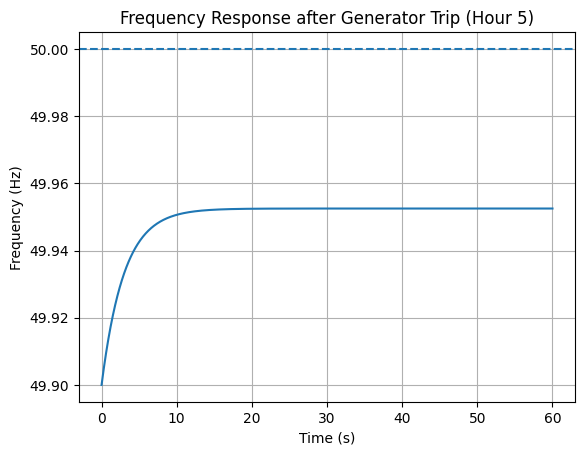

In [381]:
import numpy as np
import matplotlib.pyplot as plt

f0 = 50.0
H_sys = 5.0
tau_gov = 3.0

t = np.linspace(0, 60, 1000)

P_response = total_pfr * (1 - np.exp(-t / tau_gov))
delta_f = (P_loss - P_response) / (2 * H_sys * 100)
freq_response = f0 - delta_f

f_nadir = np.min(freq_response)
f_ss = freq_response[-1]

print("\n========== FREQUENCY BLOCK 3: SINGLE-HOUR RESPONSE ==========")
print("Frequency nadir =", round(f_nadir, 4), "Hz")
print("Steady-state frequency =", round(f_ss, 4), "Hz")

f_min = 49.5
if f_nadir >= f_min:
    print("Status: AMAN")
else:
    print("Status: TIDAK AMAN")

plt.figure()
plt.plot(t, freq_response)
plt.axhline(50, linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title(f"Frequency Response after Generator Trip (Hour {selected_hour})")
plt.grid()
plt.show()

Rekap Frekuensi Semua Jam

In [382]:
summary = []

test_hours = list(range(1, 25))

for th in test_hours:
    df_t = df_hourly[df_hourly["Hour"] == th].copy()

    dispatch = {}
    for g in gen_list:
        p = float(df_t[f"{g}_P"].iloc[0])
        u = float(df_t[f"{g}_U"].iloc[0])
        if u > 0.5 and p > 0:
            dispatch[g] = p

    trip_unit = max(dispatch, key=dispatch.get)
    P_loss = dispatch[trip_unit]

    total_reserve = sum(float(df_t[f"{g}_R"].iloc[0]) for g in gen_list)

    total_pfr = 0.0
    for g in gen_list:
        if g != trip_unit:
            total_pfr += float(df_t[f"{g}_PFR"].iloc[0])

    f0 = 50.0
    H_sys = 5.0
    tau_gov = 3.0

    t = np.linspace(0, 60, 1000)

    P_response = total_pfr * (1 - np.exp(-t / tau_gov))
    delta_f = (P_loss - P_response) / (2 * H_sys * 100)
    freq_response = f0 - delta_f

    f_nadir = np.min(freq_response)
    f_ss = freq_response[-1]

    net_deficit = P_loss - total_pfr
    pfr_ratio = total_pfr / P_loss if P_loss > 0 else 0

    summary.append([
        th,
        trip_unit,
        round(P_loss, 2),
        round(total_reserve, 2),
        round(total_pfr, 2),
        round(net_deficit, 2),
        round(pfr_ratio, 3) * 100,
        round(f_nadir, 4),
        round(f_ss, 4)
    ])

df_freq_summary = pd.DataFrame(summary, columns=[
    "t",
    "Unit Trip",
    "Ploss (MW)",
    "Total Reserve (MW)",
    "Total PFR (MW)",
    "Net Deficit (MW)",
    "PFR Ratio (%)",
    "f_nadir (Hz)",
    "f_steady (Hz)"
])

print("\n========== FREQUENCY BLOCK 4: ALL-HOUR SUMMARY ==========")
print(df_freq_summary.to_string(index=False))


========== FREQUENCY BLOCK 4: ALL-HOUR SUMMARY ==========
 t Unit Trip  Ploss (MW)  Total Reserve (MW)  Total PFR (MW)  Net Deficit (MW)  PFR Ratio (%)  f_nadir (Hz)  f_steady (Hz)
 1        G4       100.0               440.0            52.5              47.5           52.5         49.90        49.9525
 2        G4       100.0               440.0            52.5              47.5           52.5         49.90        49.9525
 3        G4       100.0               440.0            52.5              47.5           52.5         49.90        49.9525
 4        G4       100.0               440.0            52.5              47.5           52.5         49.90        49.9525
 5        G4       100.0               440.0            52.5              47.5           52.5         49.90        49.9525
 6        G4       100.0               440.0            52.5              47.5           52.5         49.90        49.9525
 7        G4       100.0               440.0            52.5              47.5  

Grafik Frekuensi

Grafik Net Deficit vs f nadir

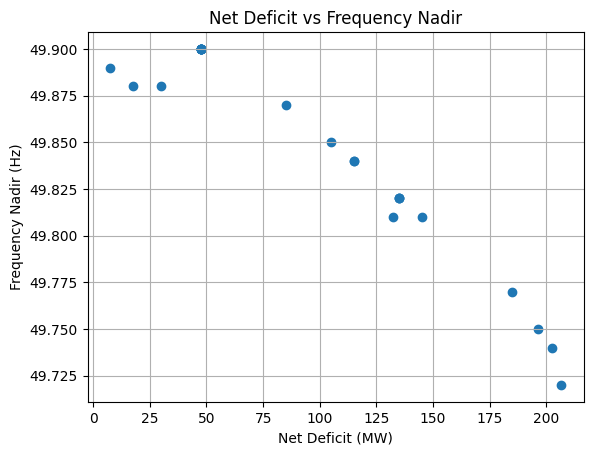

In [383]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_freq_summary["Net Deficit (MW)"], df_freq_summary["f_nadir (Hz)"])

plt.xlabel("Net Deficit (MW)")
plt.ylabel("Frequency Nadir (Hz)")
plt.title("Net Deficit vs Frequency Nadir")
plt.grid()

plt.show()

Grafik PFR Ratio vs f_nadir

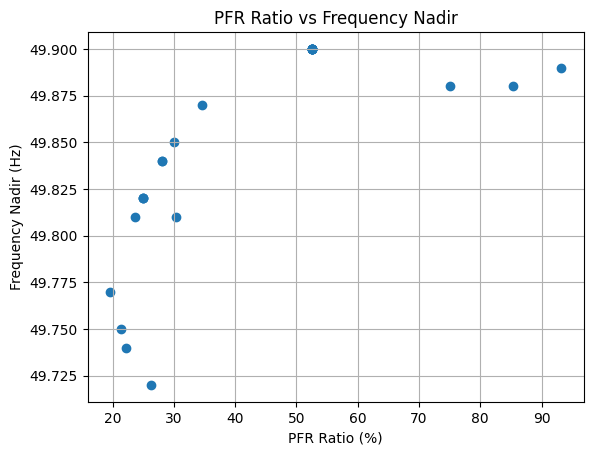

In [384]:
plt.figure()
plt.scatter(df_freq_summary["PFR Ratio (%)"], df_freq_summary["f_nadir (Hz)"])

plt.xlabel("PFR Ratio (%)")
plt.ylabel("Frequency Nadir (Hz)")
plt.title("PFR Ratio vs Frequency Nadir")
plt.grid()

plt.show()

Grafik per jam

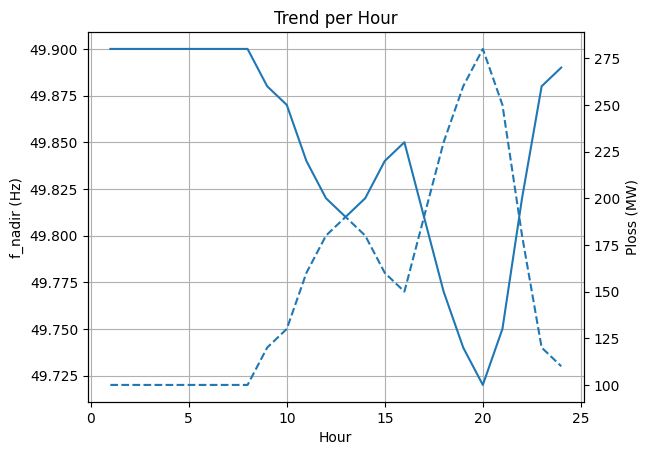

In [385]:
fig, ax1 = plt.subplots()

ax1.set_xlabel("Hour")
ax1.set_ylabel("f_nadir (Hz)")
ax1.plot(df_freq_summary["t"], df_freq_summary["f_nadir (Hz)"])
ax1.grid()

ax2 = ax1.twinx()
ax2.set_ylabel("Ploss (MW)")
ax2.plot(df_freq_summary["t"], df_freq_summary["Ploss (MW)"], linestyle='--')

plt.title("Trend per Hour")
plt.show()

Grafik

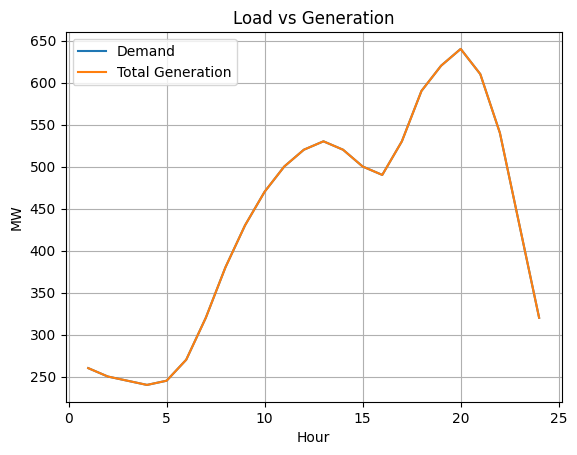

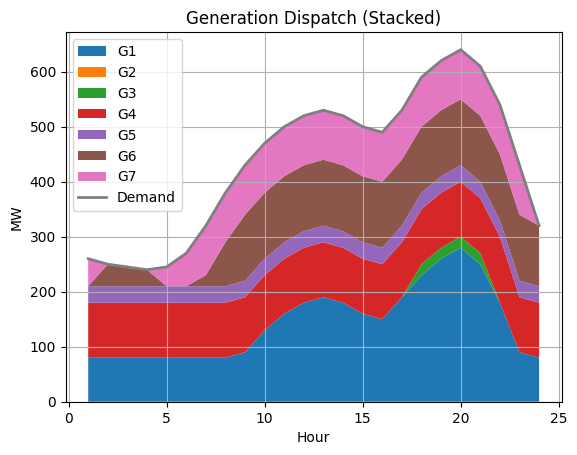

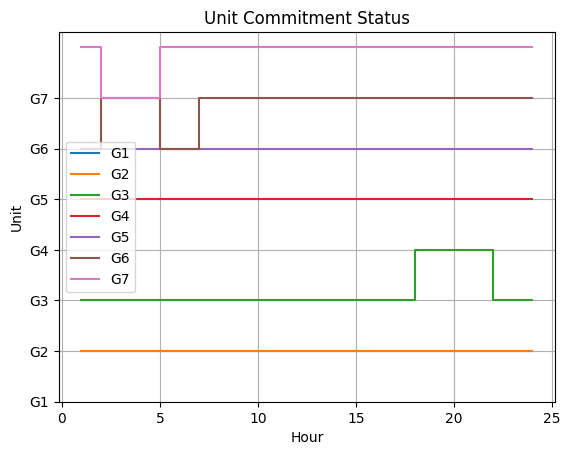

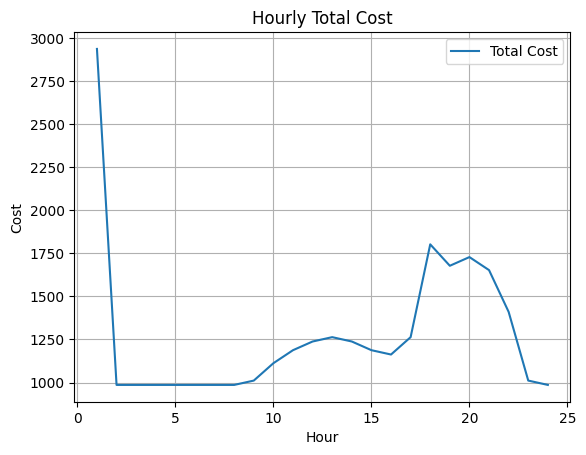

In [386]:
import matplotlib.pyplot as plt
# Mapping nama unit untuk tampilan
name_map = {
    "G1": "G1",
    "G2": "G2",
    "G3": "G3",
    "G4": "G4",
    "G5": "G5",
    "G6": "G6",
    "G7": "G7"
}

# Label Legend
plot_labels = [name_map.get(g, g) for g in model.G]

# ===============================
# 1. LOAD vs GENERATION
# ===============================
plt.figure()
plt.plot(df_hourly["Hour"], df_hourly["Demand"], label="Demand")
plt.plot(df_hourly["Hour"], df_hourly["Total_Power"], label="Total Generation")

plt.xlabel("Hour")
plt.ylabel("MW")
plt.title("Load vs Generation")
plt.legend()
plt.grid()
plt.show()

# ===============================
# 2. DISPATCH PER UNIT (STACKED)
# ===============================
gen_cols = [f"{g}_P" for g in model.G]



plt.figure()
plt.stackplot(
    df_hourly["Hour"],
    *[df_hourly[col] for col in gen_cols],
    labels=plot_labels
)

# Overlay demand
plt.plot(df_hourly["Hour"], df_hourly["Demand"], linewidth=2, label="Demand")

plt.xlabel("Hour")
plt.ylabel("MW")
plt.title("Generation Dispatch (Stacked)")
plt.legend()
plt.grid()
plt.show()


# ===============================
# 3. STATUS UNIT (ON/OFF)
# ===============================
plt.figure()

for i, g in enumerate(model.G):
    plt.step(
        df_hourly["Hour"],
        df_hourly[f"{g}_U"] + i,   # offset biar tidak numpuk
        where='post',
        label=name_map.get(g,g)
    )

plt.xlabel("Hour")
plt.ylabel("Unit")
plt.title("Unit Commitment Status")
plt.yticks(range(len(model.G)), model.G)
plt.legend()
plt.grid()
plt.show()


# ===============================
# 4. TOTAL COST PER HOUR
# ===============================
plt.figure()
plt.plot(df_hourly["Hour"], df_hourly["Total Cost"], label="Total Cost")

plt.xlabel("Hour")
plt.ylabel("Cost")
plt.title("Hourly Total Cost")
plt.legend()
plt.grid()
plt.show()